# v3 **both** hidden layers — perturbation sweeps, accuracy

Visualises the **v3L12 factorial** grid: the same experiment as
[the 1st-layer notebook](../1stLayer/result_visualization.ipynb) and
[the 2nd-layer one](../2ndLayer/results_visualization.ipynb), with the two penalties
charged at **both** hidden layers at once. A per-pair spike ceiling
`relu(count - k)` sets temporal sparsity `a` along `k`, crossed with a
membrane-potential floor setting selectivity `s` (OFF / ON), at seeds 42/43/44 —
now applied to `hidden1` **and** `hidden2`, each at the full coefficient its
single-layer sibling used.

**Why this grid exists.** Neither single-layer grid produces a sparse *network*: it
produces one sparse layer and one unconstrained layer that is free to compensate, and
under v1's layer-1-only penalty it did exactly that — ρ(`s1`, `s2`) = **−0.829** in
the no-delay arm, i.e. squeezing layer 1 made layer 2 *less* selective, and the pooled
confound ρ(`a_net`, `s_net`) sat at **−0.879**. This grid is the same factorial moved
to the whole network (document 7 §1).

| arm | grid | checkpoints | row axis |
|---|---|---|---|
| no-delay | 4 `k` × 2 floor × 3 seeds | 24 | `k1 = 1, 2, 4, 8`, `k2 = k1 × 1.0` |
| with-delay | 4 `k` × 2 floor × 3 seeds | 24 | `k1 = 1, 2, 4, 8`, `k2 = k1 × **2.0**` |

`CEILING_K` lists **layer 1's** levels; layer 2's are `CEILING_K_LAYER2_RATIO` times
them, so one row knob delivers an equal *relative* cut at both layers. The delay arm's
layer 2 fires about twice as hard as its layer 1 (natural `a` 20.7–30.4 against
3.8–15.5), which is where the ×2 comes from (document 7 §3a). The delay arm also
carries `SETTLE_EPOCHS = 150`; the no-delay arm deliberately does not (document 7
§5 step 1b).

## Three injection sites, three sections

The independent variables here are pooled over both layers, but **the dependent
variable need not be** — document 7 §5 step 3 is explicit that perturbing both layers
at once is a *different and harsher* insult than perturbing either, and that per-layer
results are the primary reading with the pooled one an addition. Every eval file
therefore carries three sweeps per cell, under `sites = ['l1', 'l2', 'both']`, and
this notebook gives each its own section:

| § | site | what is perturbed | non-sparse baseline |
|---|---|---|---|
| 3 | `l1` | `hidden1` only, window `[0, 88)` | `FWP_log/*_whole_{arm}_*` |
| 4 | `l2` | `hidden2` only, window `[0, 90)` / `[0, 160)` | `FWP_log/*_2ndLayer_whole_{arm}_*` |
| 5 | `both` | `hidden1` **and** `hidden2`, each in its own window | **none exists** — see §5 |

The delay arm's layer-2 window is nearly twice layer 1's because `delay1` sits
*upstream* of that probe site and pushes layer 2's spikes as late as bin 159.

| perturbation | what it destroys | rate-preserving? | clipped to the window? |
|---|---|---|---|
| relocation | spike placement, count held exactly | yes | yes |
| jitter | spike placement, locally | yes | yes |
| shift | cross-neuron alignment (rigid per-neuron translation) | yes | **no** — deliberately |
| deletion | spikes themselves — the **general-robustness control** | **no** | n/a |

Shift and deletion are left unclipped on purpose: clipping a rigid translation would
pile spikes at the edge and merge them, turning a timing probe into a rate insult.

Every v3L12 point is the **mean over the cell's 3 seeds**; bands and error bars are
the across-seed standard deviation, read from the `per_setup` section of each results
file (the per-seed rows are kept in `per_checkpoint`). The baseline is a single model
per arm, with its own 3 perturbation repeats.

**Encoding.** `k` is an *ordered* variable, so it gets a single-hue ramp
(light → dark as `k` rises). The floor is *binary*, so it gets line style rather than
a hue. The baseline is not a cell of the factorial, so it takes neutral ink and a
dash-dot line rather than a colour slot. In §6, where the three sites are compared
directly, the **site** becomes the categorical variable and gets its own three hues.

> **Caveats on the baseline, carried over from both sibling notebooks.**
>
> 1. **The jitter panels are not strictly like-for-like.** The v3L12 jitter sweeps
>    clip jittered spikes to each layer's measured support; the baseline's jitter
>    (generated 2026-07-15) clips to the full `[0, T-1]` window. Jitter is local so
>    the artifact is small (≤ .026 at layer 1, document 5 §2a), but it biases the
>    baseline *downward* relative to the v3L12 curves. Relocation is fine (those
>    baselines were regenerated 2026-07-31 with support-confined destinations), and
>    shift and deletion have no destination window to correct.
> 2. **The eight baseline files do not all agree on clean accuracy** — the four
>    layer-1 files come from separate runs of the same non-sparse configuration
>    (delay .871–.890, no-delay .572–.584) while the four layer-2 files agree exactly
>    (.890 / .584). Each panel uses its own file's baseline, so every panel is
>    internally consistent; §1 draws the spread as a band rather than pretending
>    there is one number. The check is made in code.
> 3. **The relocation baseline sweep stops at `f = 0.9`** where the v3L12 sweep runs
>    to `f = 1.0`, so that one baseline curve ends one grid point short. The tables in
>    §7 label the baseline column accordingly.

The scoring, the regressions on `a` and `s`, and the H1′/H2 verdict live in
[sparse_network_bothLayer_test_progress.md](../../../docs/progress/sparse_network_bothLayer_test_progress.md)
and in the `v3_analysis/` scripts. This notebook plots **accuracy**, plus the
manipulation check (§7).

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline


# Anchor on exp_sparse_network/ by walking up from wherever the notebook runs,
# so this works from the notebook's own directory or from the repo root.
def find_experiment_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "shd" / "log").is_dir() and (candidate / "sn_data").is_dir():
            return candidate
        nested = candidate / "my_project" / "exp_sparse_network"
        if (nested / "shd" / "log").is_dir():
            return nested
    raise FileNotFoundError("could not locate exp_sparse_network/")


EXP_DIR = find_experiment_root()
FWP_DIR = EXP_DIR / "result_visualization" / "bothLayer" / "FWP_log"
print(f"experiment root: {EXP_DIR}")
print(f"baseline logs  : {FWP_DIR}")

# (label, folder, v3L12 file stem, sweep key prefix, {site -> baseline template},
#  x-axis label). The sweep key is `{prefix}_{site}`, e.g. "f_sweep_l1"; the
# `both` site has no non-sparse baseline, which is why the dict has two entries.
PERTURBATIONS = [
    ("relocation", "shd", "shd", "f_sweep",
     {"l1": "shd_whole_{arm}_hidden_perturbation_results.json",
      "l2": "shd_2ndLayer_whole_{arm}_hidden_perturbation_results.json"},
     "fraction of spikes relocated  f"),
    ("jitter", "jitter", "jitter", "sigma_sweep",
     {"l1": "jitter_whole_{arm}_jitter_sweep_results.json",
      "l2": "jitter_2ndLayer_whole_{arm}_evalOnly_jitter_sweep_results.json"},
     "jitter sigma  (ms)"),
    ("shift", "shift", "shift", "sigma_sweep",
     {"l1": "shift_whole_{arm}_shift_sweep_results.json",
      "l2": "shift_2ndLayer_whole_{arm}_evalOnly_shift_sweep_results.json"},
     "shift sigma  (ms)"),
    ("deletion", "deletion", "deletion", "pd_sweep",
     {"l1": "deletion_whole_{arm}_evalOnly_deletion_sweep_results.json",
      "l2": "deletion_2ndLayer_whole_{arm}_evalOnly_deletion_sweep_results.json"},
     "deletion probability  p_d"),
]
ARMS = [("nodelay", "no-delay arm"), ("delay", "with-delay arm")]
SITES = [("l1", "hidden layer 1"), ("l2", "hidden layer 2"),
         ("both", "both hidden layers")]

CHANCE = 1.0 / 20

# Unconstrained firing measured on the 27 v1 checkpoints (document 7 §2a) -- the
# reference each ceiling is pushing down from, per layer and pooled over the pair.
NATURAL_A = {
    "nodelay": {"l1": (3.06, 11.49), "l2": (7.49, 12.46), "net": (5.47, 11.87)},
    "delay": {"l1": (3.82, 15.47), "l2": (20.71, 30.44), "net": (14.47, 22.60)},
}
# Observational rho from the same pass. The pooled figure is the acceptance
# target: -0.879 fails |rho| <= 0.5 in the no-delay arm, +0.042 already passes in
# the delay arm. `s1s2` is the design's motivating finding, not an acceptance
# criterion -- it must come back POSITIVE or the column knob is not a
# network-wide selectivity manipulation.
OBSERVED_RHO = {
    "nodelay": {"l1": -0.943, "l2": +0.829, "net": -0.879, "s1s2": -0.829},
    "delay": {"l1": -0.455, "l2": +0.427, "net": +0.042, "s1s2": +0.203},
}
# Each layer's own measured temporal support, per arm (document 7 §5 step 3).
SUPPORT_BINS = {"nodelay": {"l1": 88, "l2": 90}, "delay": {"l1": 88, "l2": 160}}

# `k` is ordered -> one-hue ordinal ramp, light to dark. The floor is binary ->
# line style, not hue. Both arms carry the same four rows, so four steps.
K_COLOURS = {1.0: "#86b6ef", 2.0: "#5598e7", 4.0: "#2a78d6", 8.0: "#184f95"}
FLOOR_STYLE = {0.0: dict(linestyle="--", marker="o", markerfacecolor="white"),
               1.0: dict(linestyle="-", marker="o")}
FLOOR_COLOUR = {0.0: "#2a78d6", 1.0: "#eb6834"}
# In §6 the injection site is the categorical variable and takes the hues.
SITE_COLOUR = {"l1": "#2a78d6", "l2": "#eb6834", "both": "#6a4c93"}

INK, INK_MUTED, GRID = "#0b0b0b", "#52514e", "#d8d7d2"

# The non-sparse baseline is a reference, not a series: neutral ink, dash-dot.
BASELINE_STYLE = dict(color=INK, linestyle="-.", marker="s", markersize=4.5,
                      linewidth=2.2, zorder=5)


def load_results(arm: str, folder: str, stem: str) -> dict:
    """Return the whole v3L12 results file for one arm and one perturbation."""
    path = EXP_DIR / folder / "log" / f"sparse_whole_{arm}_v3L12_{stem}_eval.json"
    return json.loads(path.read_text())


def load_per_setup(arm: str, folder: str, stem: str) -> dict:
    """Return the seed-averaged v3L12 rows for one arm and one perturbation."""
    return load_results(arm, folder, stem)["per_setup"]


def load_baseline(arm: str, templates: dict, site: str):
    """Return the non-sparse sweep for one site: {grid point -> (mean, std)}.

    The `both` site has no non-sparse counterpart, so this returns None there.
    """
    if site not in templates:
        return None
    raw = json.loads((FWP_DIR / templates[site].format(arm=arm)).read_text())
    return {float(point): (entry["mean"], entry["std"])
            for point, entry in raw.items()}


def k_levels(arm: str) -> list:
    """Return layer 1's ceiling levels actually present in this arm's grid."""
    rows = load_per_setup(arm, "shd", "shd").values()
    return sorted({row["ceiling_k"] for row in rows})


def k_ratio(arm: str) -> float:
    """Return CEILING_K_LAYER2_RATIO as recorded in the checkpoints themselves."""
    rows = load_results(arm, "shd", "shd")["per_checkpoint"].values()
    ratios = {row["ceiling_k_layer2_ratio"] for row in rows}
    if len(ratios) != 1:
        raise ValueError(f"{arm}: inconsistent layer-2 ratio {ratios}")
    return float(ratios.pop())


def k_tick_labels(arm: str) -> list:
    """Label the row axis with both layers' ceilings when they differ."""
    ratio = k_ratio(arm)
    if ratio == 1.0:
        return [f"{k:g}" for k in k_levels(arm)]
    return [f"{k:g}\n({k * ratio:g})" for k in k_levels(arm)]


def k_axis_label(arm: str) -> str:
    """Name the row axis, spelling out layer 2's scaled ceiling when it differs."""
    if k_ratio(arm) == 1.0:
        return "ceiling  k  (both layers)"
    return f"ceiling  k1   (k2 = k1 x {k_ratio(arm):g}, in brackets)"


def style_axis(axis) -> None:
    """Recessive grid and spines, so the data carries the ink."""
    axis.grid(True, color=GRID, linewidth=0.6, alpha=0.9)
    axis.set_axisbelow(True)
    for side in ("top", "right"):
        axis.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        axis.spines[side].set_color(GRID)
    axis.tick_params(colors=INK_MUTED, labelsize=9)


# Check that all eight v3L12 files carry all three sites, that every cell really
# carries three seeds, and that all eight baseline files are present.
for arm, _ in ARMS:
    windows = SUPPORT_BINS[arm]
    print(f"{arm}  (target layers [1, 2], k2 = k1 x {k_ratio(arm):g}, "
          f"windows L1 [0, {windows['l1']}) / L2 [0, {windows['l2']}))")
    for label, folder, stem, prefix, templates, _ in PERTURBATIONS:
        results = load_results(arm, folder, stem)
        rows = results["per_setup"]
        layers = {tuple(row["target_layers"])
                  for row in results["per_checkpoint"].values()}
        seeds = {row["n_seeds"] for row in rows.values()}
        cleans = {site: load_baseline(arm, templates, site)
                  for site, _ in SITES}
        clean_text = "  ".join(
            f"{site} {sweep[min(sweep)][0]:.3f}" if sweep else f"{site} --"
            for site, sweep in cleans.items())
        print(f"  {label:<11} v3L12: {len(rows)} setups, "
              f"{len(results['per_checkpoint'])} checkpoints, seeds {seeds}, "
              f"target_layers {layers}, sites {results['sites']}  |  "
              f"baseline clean: {clean_text}")

experiment root: d:\IC_2025\IRP\workspace\my_project\exp_sparse_network
baseline logs  : d:\IC_2025\IRP\workspace\my_project\exp_sparse_network\result_visualization\bothLayer\FWP_log
nodelay  (target layers [1, 2], k2 = k1 x 1, windows L1 [0, 88) / L2 [0, 90))
  relocation  v3L12: 8 setups, 24 checkpoints, seeds {3}, target_layers {(1, 2)}, sites ['l1', 'l2', 'both']  |  baseline clean: l1 0.584  l2 0.584  both --
  jitter      v3L12: 8 setups, 24 checkpoints, seeds {3}, target_layers {(1, 2)}, sites ['l1', 'l2', 'both']  |  baseline clean: l1 0.572  l2 0.584  both --
  shift       v3L12: 8 setups, 24 checkpoints, seeds {3}, target_layers {(1, 2)}, sites ['l1', 'l2', 'both']  |  baseline clean: l1 0.572  l2 0.584  both --
  deletion    v3L12: 8 setups, 24 checkpoints, seeds {3}, target_layers {(1, 2)}, sites ['l1', 'l2', 'both']  |  baseline clean: l1 0.573  l2 0.584  both --
delay  (target layers [1, 2], k2 = k1 x 2, windows L1 [0, 88) / L2 [0, 160))
  relocation  v3L12: 8 setups, 24 

## 1. Clean accuracy across the grid

The unperturbed accuracy every curve in §3–§5 starts from. Worth reading before any
perturbation result: a normalised damage score divides by this number, so a cell whose
clean accuracy is unusual will move the score for reasons that have nothing to do with
timing.

The dash-dot line is the non-sparse network's clean accuracy, and the band around it is
the spread across the eight baseline files. That spread is run-to-run variation of the
same non-sparse configuration, not a site effect — clean accuracy is a property of the
model, and the perturbation site cannot change it.

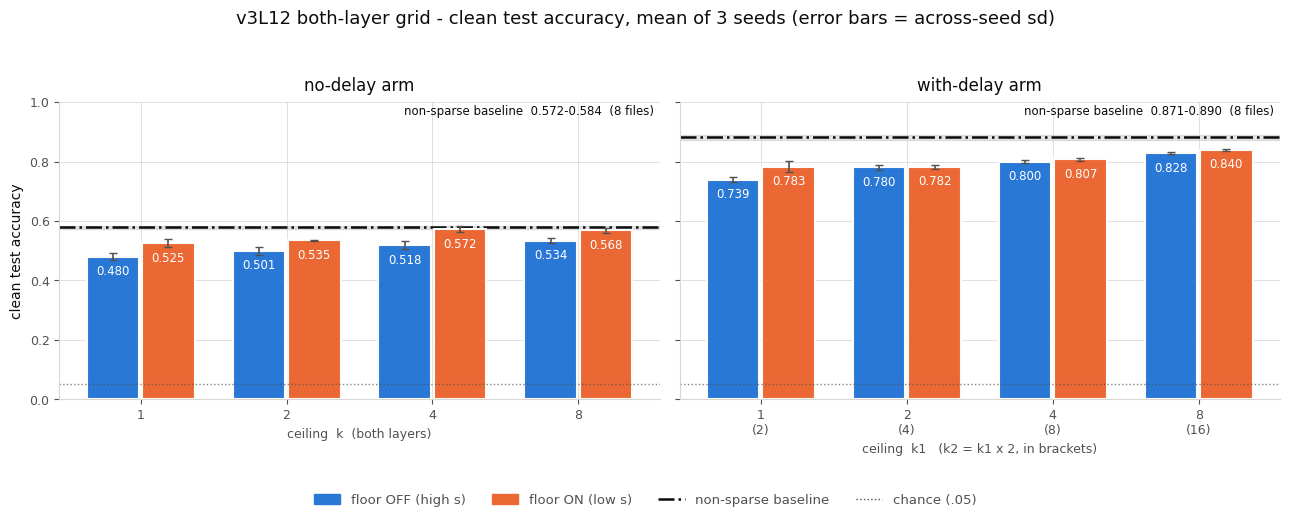

In [2]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
width = 0.36

for col, (arm, arm_label) in enumerate(ARMS):
    axis = axes[col]
    per_setup = load_per_setup(arm, "shd", "shd")
    levels = k_levels(arm)
    positions = np.arange(len(levels))

    # Non-sparse reference: every baseline file's own clean accuracy, both sites.
    clean_baselines = []
    for *_, templates, _ in PERTURBATIONS:
        for site in ("l1", "l2"):
            clean_baselines.append(load_baseline(arm, templates, site)[0.0][0])
    low, high = min(clean_baselines), max(clean_baselines)
    if high - low > 1e-9:
        axis.axhspan(low, high, color=INK, alpha=0.10, zorder=0)
        caption = f"non-sparse baseline  {low:.3f}-{high:.3f}  (8 files)"
    else:
        caption = f"non-sparse baseline  {low:.3f}  (all 8 files agree)"
    axis.axhline(float(np.mean(clean_baselines)), color=INK, linestyle="-.",
                 linewidth=1.8, zorder=1)
    # Caption in the corner, not on the line: the bars can sit either side of the
    # baseline, so a label anchored to it would land on top of them.
    axis.text(0.99, 0.99, caption, transform=axis.transAxes, ha="right",
              va="top", fontsize=8.5, color=INK)

    for index, floor in enumerate([0.0, 1.0]):
        rows = [per_setup[f"k{k:g}_floor{floor:g}"] for k in levels]
        means = [row["clean_acc"] for row in rows]
        errs = [row["clean_acc_std"] for row in rows]
        offset = (index - 0.5) * (width + 0.02)
        axis.bar(positions + offset, means, width, yerr=errs, capsize=3,
                 color=FLOOR_COLOUR[floor], edgecolor="#fcfcfb", linewidth=1.5,
                 error_kw=dict(ecolor=INK_MUTED, lw=1.2), zorder=2)
        # Values sit inside the bar, so they cannot collide with the baseline.
        for position, value in zip(positions + offset, means):
            axis.text(position, value - 0.028, f"{value:.3f}", ha="center",
                      va="top", fontsize=8.5, color="#ffffff", zorder=3)

    axis.axhline(CHANCE, color=INK_MUTED, linewidth=1, linestyle=":", alpha=0.7)
    axis.set_xticks(positions)
    axis.set_xticklabels(k_tick_labels(arm))
    axis.set_xlabel(k_axis_label(arm), fontsize=9, color=INK_MUTED)
    style_axis(axis)
    axis.set_title(arm_label, fontsize=12, color=INK, pad=8)
    if col == 0:
        axis.set_ylabel("clean test accuracy", fontsize=10, color=INK)

axes[0].set_ylim(0.0, 1.0)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=FLOOR_COLOUR[0.0], label="floor OFF (high s)"),
    plt.Rectangle((0, 0), 1, 1, color=FLOOR_COLOUR[1.0], label="floor ON (low s)"),
    plt.Line2D([], [], color=INK, linestyle="-.", linewidth=1.8,
               label="non-sparse baseline"),
    plt.Line2D([], [], color=INK_MUTED, linewidth=1, linestyle=":",
               label="chance (.05)"),
]
figure.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
              fontsize=9.5, labelcolor=INK_MUTED, bbox_to_anchor=(0.5, -0.08))
figure.suptitle("v3L12 both-layer grid - clean test accuracy, mean of 3 seeds "
                "(error bars = across-seed sd)", fontsize=13, color=INK)
figure.tight_layout(rect=(0, 0.02, 1, 0.94))
plt.show()

## 2. How to read the three site sections

Sections 3, 4 and 5 are the **same figure three times**, differing only in where the
perturbation was injected. Rows are the two arms, columns the four perturbations, and
all eight panels of a figure share one y-axis so the arms can be compared directly —
the no-delay arm simply starts much lower.

Two readings per panel, and they are independent of each other:

- the **spread between the coloured curves** is what the factorial is about — a panel
  where the coloured curves lie on top of one another says the perturbation does not
  distinguish the cells, whatever it does to accuracy;
- the **gap to the black baseline** is what the sparsity penalty cost. Note that this
  is not a like-for-like comparison of *robustness*: the baseline is a different, more
  accurate model, so a curve below it may simply be starting lower (§1).

The three figures share one plotting function, defined below, so that nothing but the
site can differ between them.

**One thing the three sections cannot settle between them.** ρ(`a1`, `a2`) is +0.96 /
+0.84 observationally and both knobs here act on both layers, so `a1` and `a2` move
together **by construction** (document 7 §2b point 4). Comparing the `l1` and `l2`
sections tells you where the *insult* lands, not which layer's sparsity caused an
effect. Attribution is what the two single-layer grids are for.

In [3]:
def plot_site_sweeps(site: str, site_label: str, note: str = "") -> None:
    """Draw the 2 arms x 4 perturbations accuracy figure for one injection site.

    Args:
        site: one of "l1", "l2", "both" -- selects the `{prefix}_{site}` sweeps.
        site_label: human-readable site name for the figure title.
        note: optional line appended to the title, e.g. why a baseline is missing.
    """
    figure, axes = plt.subplots(2, 4, figsize=(17, 8), sharey=True)
    drew_baseline = False

    for row, (arm, arm_label) in enumerate(ARMS):
        for col, (label, folder, stem, prefix, templates, xlabel) in \
                enumerate(PERTURBATIONS):
            axis = axes[row][col]
            field = f"{prefix}_{site}"

            for entry in load_per_setup(arm, folder, stem).values():
                grid = [float(point) for point in entry[field]]
                means = np.array([entry[field][p]["mean"] for p in entry[field]])
                stds = np.array([entry[field][p]["std"] for p in entry[field]])
                colour = K_COLOURS[entry["ceiling_k"]]
                axis.plot(grid, means, color=colour, linewidth=2, markersize=5,
                          markeredgecolor=colour,
                          **FLOOR_STYLE[entry["floor_strength"]])
                axis.fill_between(grid, means - stds, means + stds,
                                  color=colour, alpha=0.15, linewidth=0)

            baseline = load_baseline(arm, templates, site)
            if baseline is not None:
                drew_baseline = True
                points = sorted(baseline)
                base_means = np.array([baseline[p][0] for p in points])
                base_stds = np.array([baseline[p][1] for p in points])
                axis.plot(points, base_means, **BASELINE_STYLE)
                axis.fill_between(points, base_means - base_stds,
                                  base_means + base_stds, color=INK, alpha=0.12,
                                  linewidth=0, zorder=4)

            axis.axhline(CHANCE, color=INK_MUTED, linewidth=1, linestyle=":",
                         alpha=0.7)
            style_axis(axis)
            axis.set_xlabel(xlabel, fontsize=9, color=INK_MUTED)
            if col == 0:
                axis.set_ylabel(f"{arm_label}\ntest accuracy", fontsize=10,
                                color=INK)
            if row == 0:
                axis.set_title(label, fontsize=12, color=INK, pad=8)

    axes[0][0].set_ylim(0.0, 1.0)

    ratios = {k_ratio(arm) for arm, _ in ARMS}
    k_note = "" if ratios == {1.0} else "  (layer 2 at k1 x1 no-delay, x2 delay)"
    handles = [plt.Line2D([], [], color=colour, linewidth=2.5,
                          label=f"ceiling k1 = {k:g}")
               for k, colour in K_COLOURS.items()]
    handles += [
        plt.Line2D([], [], color=INK_MUTED, linewidth=2, linestyle="--",
                   marker="o", markerfacecolor="white", markersize=5,
                   label="floor OFF (high s)"),
        plt.Line2D([], [], color=INK_MUTED, linewidth=2, linestyle="-",
                   marker="o", markersize=5, label="floor ON (low s)"),
    ]
    if drew_baseline:
        handles.append(plt.Line2D([], [], label="non-sparse baseline (no penalty)",
                                  **BASELINE_STYLE))
    handles.append(plt.Line2D([], [], color=INK_MUTED, linewidth=1, linestyle=":",
                              label="chance (.05)"))
    figure.legend(handles=handles, loc="lower center", ncol=4, frameon=False,
                  fontsize=9.5, labelcolor=INK_MUTED, bbox_to_anchor=(0.5, -0.07))

    title = (f"v3L12 both-layer grid - perturbation injected at {site_label} "
             f"({site}) - test accuracy, mean of 3 seeds (band = across-seed sd)"
             f"{k_note}")
    if note:
        title += f"\n{note}"
    figure.suptitle(title, fontsize=13, color=INK)
    figure.tight_layout(rect=(0, 0.08, 1, 0.96))
    plt.show()


print("plot_site_sweeps() ready -- sites:",
      ", ".join(site for site, _ in SITES))

plot_site_sweeps() ready -- sites: l1, l2, both


## 3. Perturbation injected at **hidden layer 1** (`site = l1`)

`hidden1` is perturbed inside its measured support `[0, 88)`, in both arms; `hidden2`
is left alone and receives whatever layer 1 now emits. This is the sweep that is
directly comparable, cell for cell, with the
[1st-layer grid](../1stLayer/result_visualization.ipynb) — same `k`, same floor, same
seeds, same window, same probe — the only difference being that here layer 2 is also
under penalty during training.

Its baseline is `FWP_log/*_whole_{arm}_*`: the non-sparse network perturbed at *its*
first hidden layer.

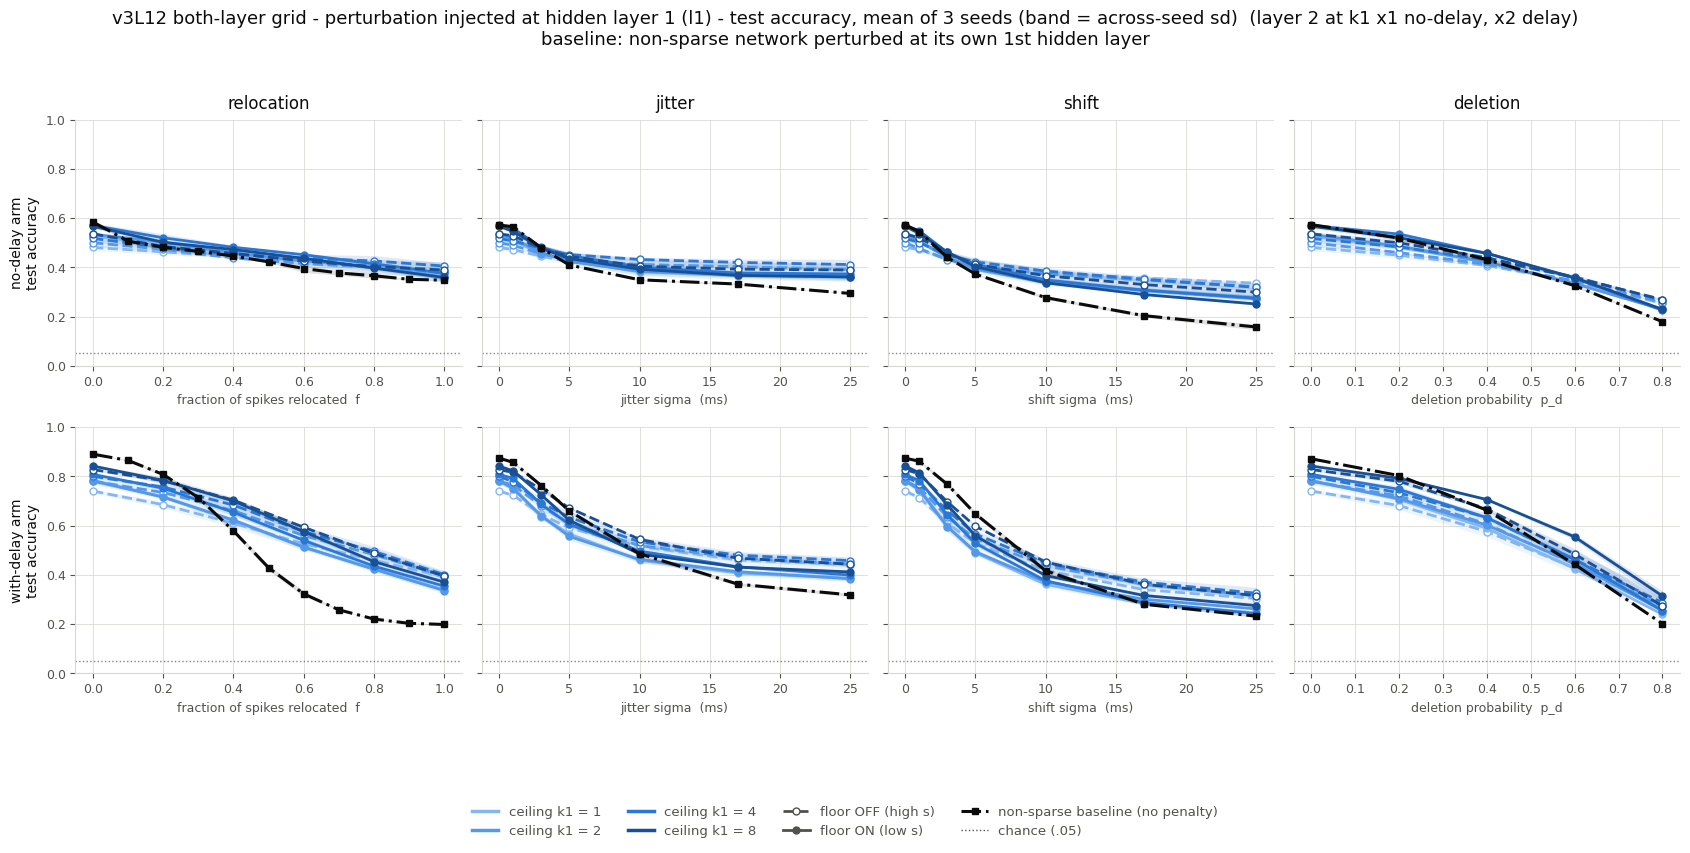

In [4]:
plot_site_sweeps("l1", "hidden layer 1",
                 "baseline: non-sparse network perturbed at its own 1st hidden layer")

## 4. Perturbation injected at **hidden layer 2** (`site = l2`)

`hidden2` is perturbed inside its own measured support — `[0, 90)` in the no-delay arm
but `[0, 160)` in the delay arm, because `delay1` sits *upstream* of this probe site
and pushes layer 2's spikes as late as bin 159. `hidden1` is left intact, so the code
that reaches the readout has already been re-encoded once by `fc2` before the insult
lands.

Getting the delay handling wrong here would silently measure the wrong tensor rather
than raise an error (document 7 §5 step 3), which is why the window is per layer *and*
per arm rather than a single constant.

Its baseline is `FWP_log/*_2ndLayer_whole_{arm}_*`: the non-sparse network perturbed at
*its* second hidden layer. Comparing this section against §3 says how much of the
network's timing sensitivity sits at each depth — but see §2 on what it cannot say.

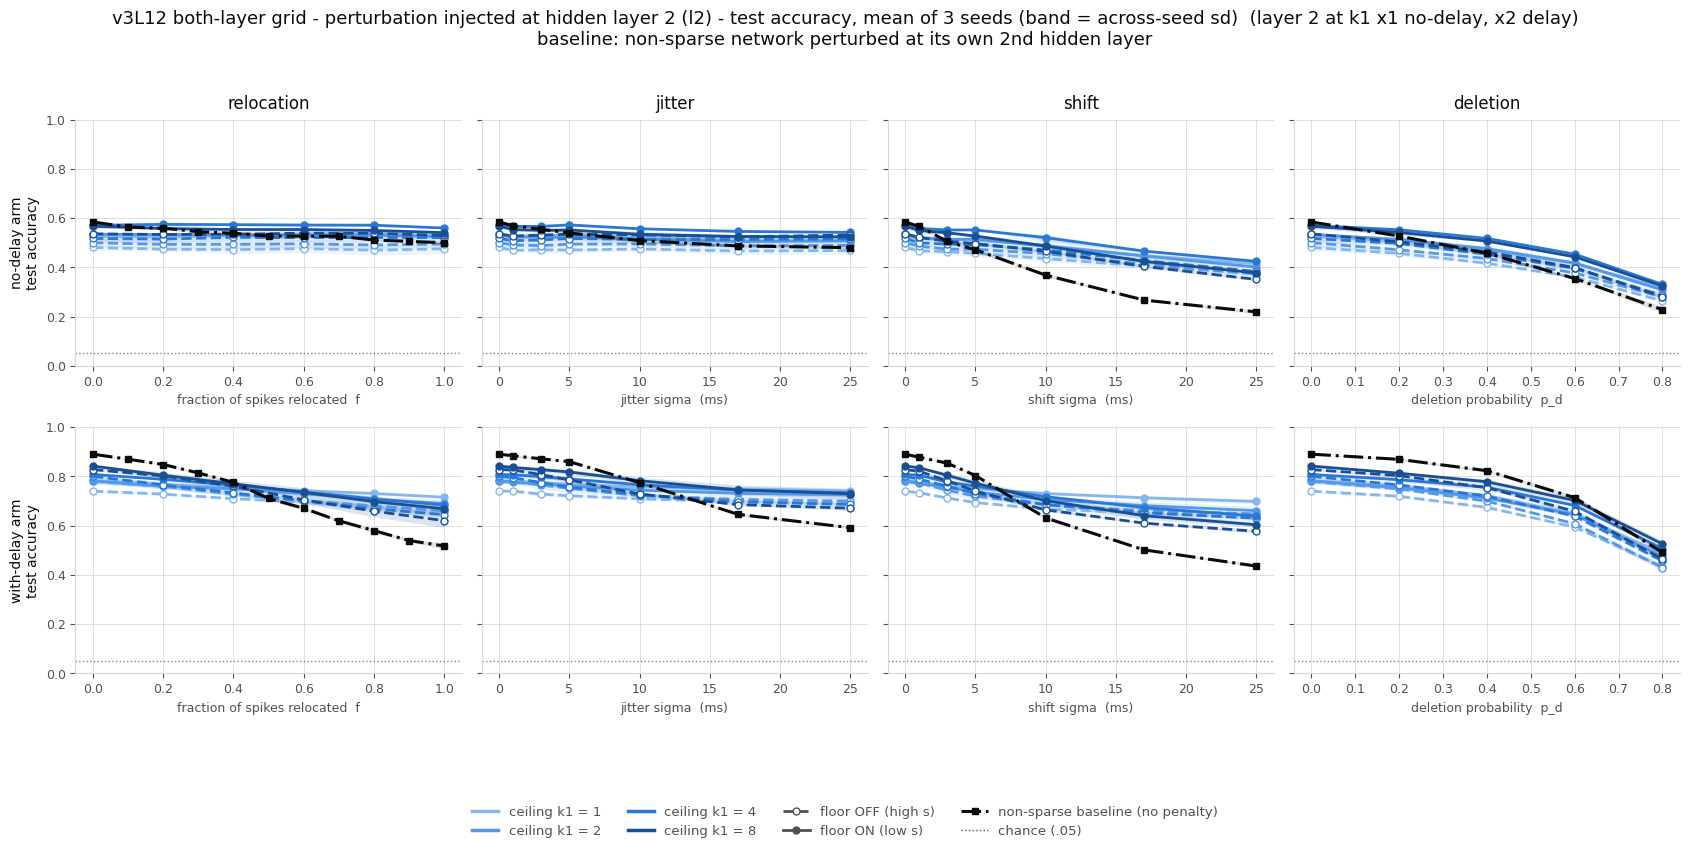

In [5]:
plot_site_sweeps("l2", "hidden layer 2",
                 "baseline: non-sparse network perturbed at its own 2nd hidden layer")

## 5. Perturbation injected at **both hidden layers** (`site = both`)

Both hidden layers are perturbed in the same pass, each inside its own window. This is
the site that matches the independent variable: the grid manipulates the whole network,
and this sweep insults the whole network.

**It is a harsher insult than either single-layer sweep, and not a sum of them.** The
perturbation at layer 1 changes what layer 2 receives, and layer 2 is then perturbed
again on top of that — the damage compounds through the depth rather than adding. Read
this section as its own quantity, not as a check on §3 and §4.

> **There is no non-sparse baseline for this site.** The
> `exp_fixed_weight_perturbation` sweeps were only ever generated one layer at a time,
> so `FWP_log/` has a `*_whole_*` set and a `*_2ndLayer_whole_*` set and nothing that
> perturbs both. The panels below therefore carry no black reference line, and the code
> omits it rather than substituting one of the single-layer files — which would put a
> strictly gentler insult on the same axes and read as if the sparse networks had done
> badly. Producing the missing baseline is a one-script job if this comparison is ever
> needed.

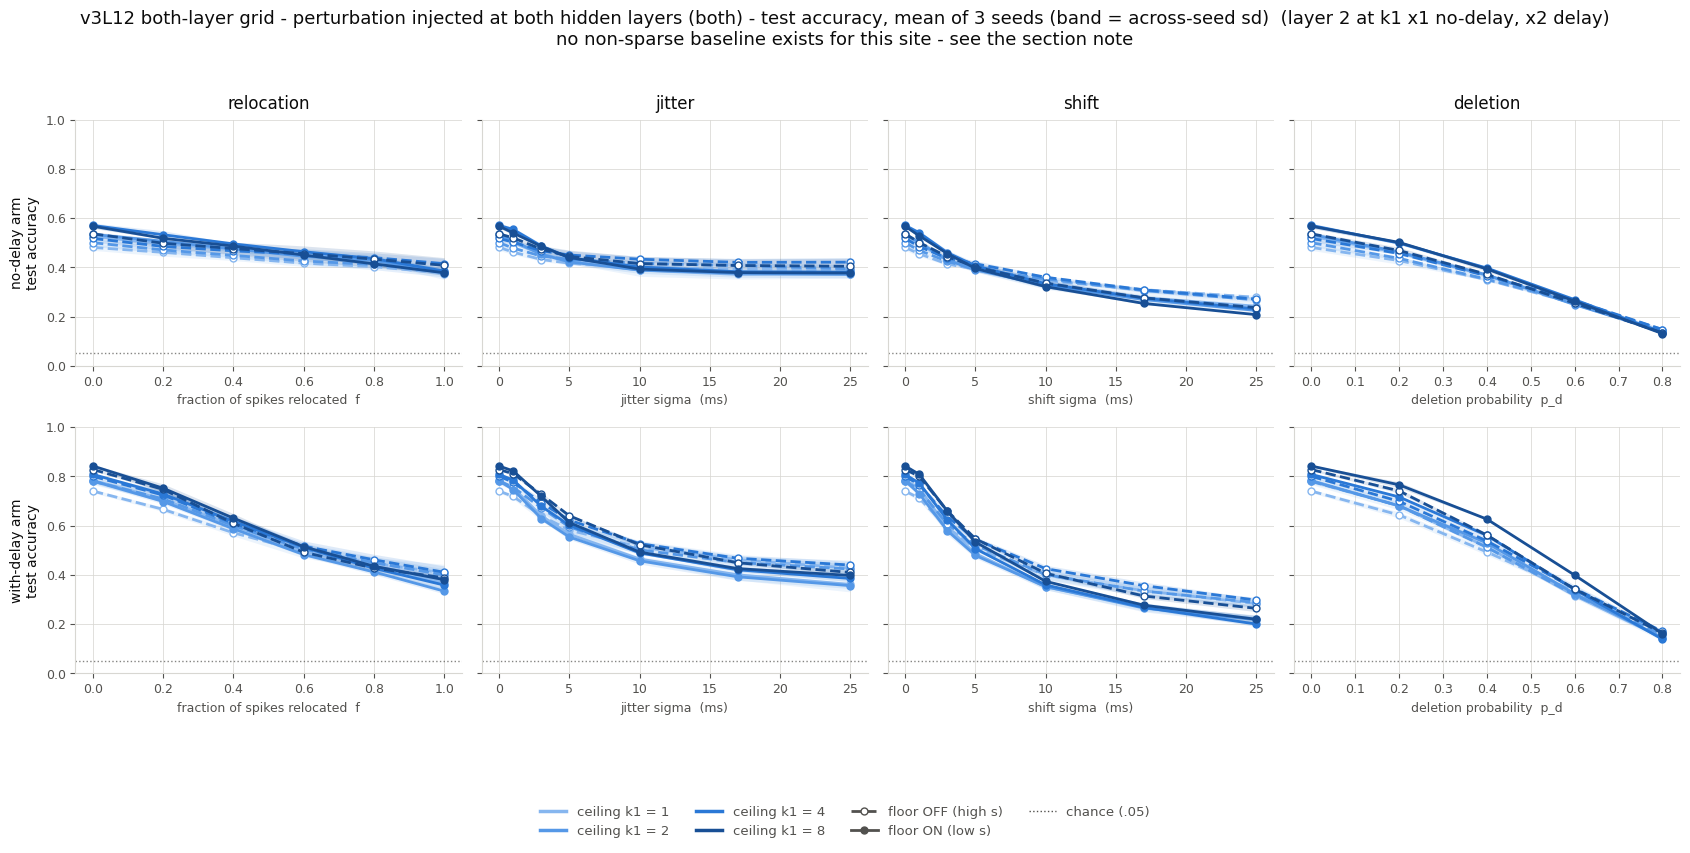

In [6]:
plot_site_sweeps("both", "both hidden layers",
                 "no non-sparse baseline exists for this site - see the section note")

## 6. The three sites side by side

Sections 3–5 each hold the site fixed and let the grid vary. This one does the
opposite: it collapses the grid to show what changes when the *site* moves.

- **left figure** — the sweep averaged over all 8 setups, one curve per site, with the
  band spanning the setups. It answers "where does this perturbation hurt?" without the
  factorial in the way.
- **right figure** — chance-corrected retention at the end of each sweep,
  `(acc_end − .05) / (acc_clean − .05)`, read straight from the `retention_{site}` keys.
  1.0 means the perturbation cost nothing; 0.0 means it took the model to chance. Bars
  are the mean over the four `k` rows, error bars the spread across them, split by floor
  setting so the column knob stays visible.

Here the **site** is the categorical variable, so it takes the three hues; `k` is
averaged away and the floor stays as the within-group split.

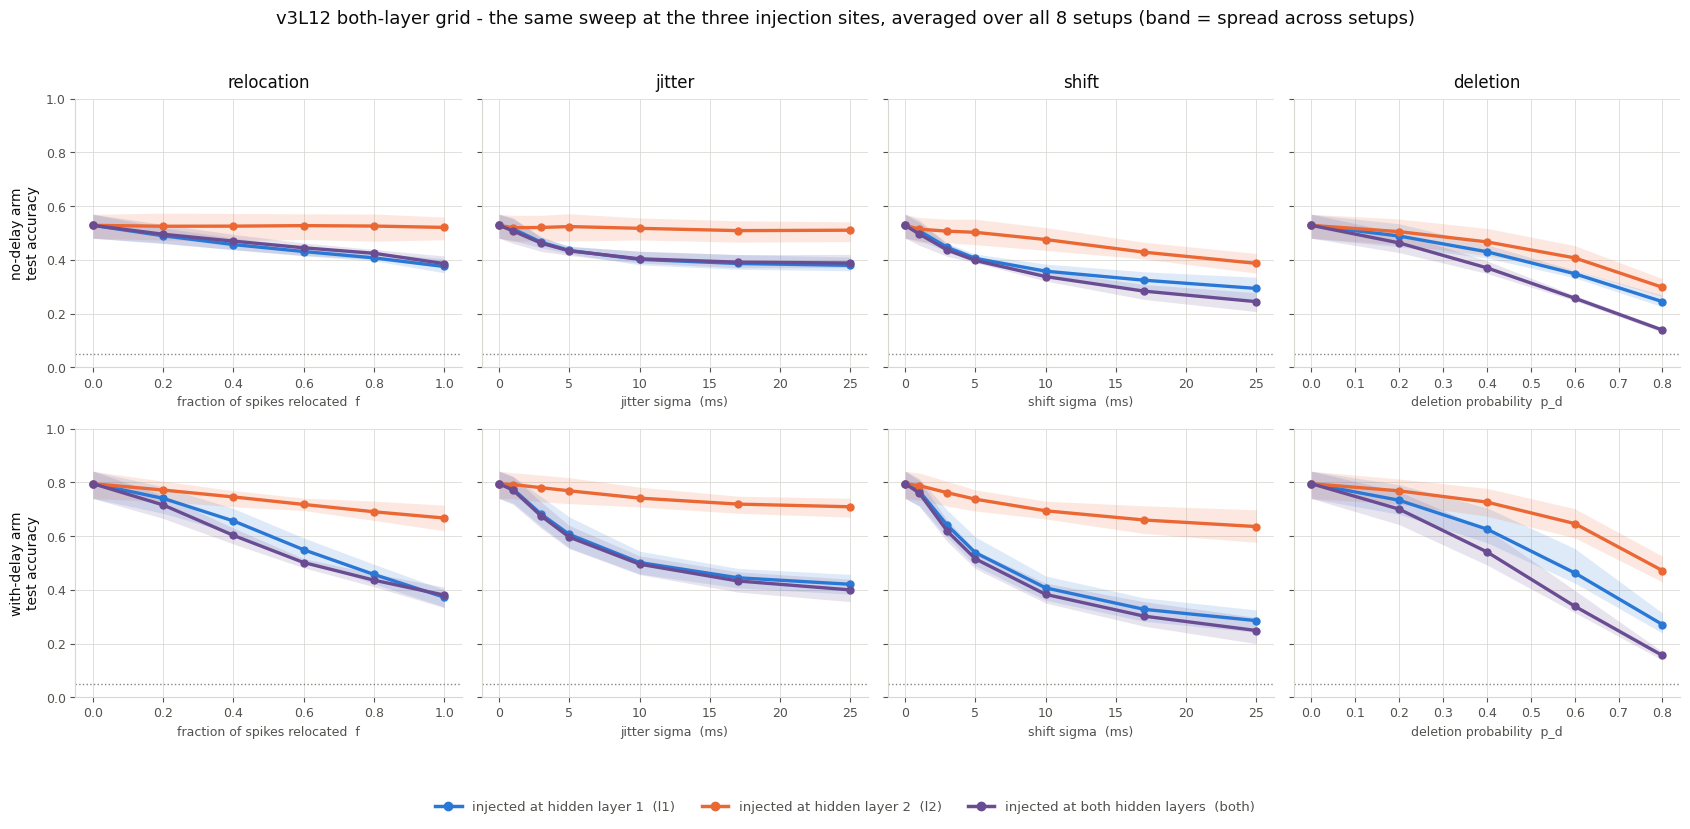

In [7]:
figure, axes = plt.subplots(2, 4, figsize=(17, 8), sharey=True)

for row, (arm, arm_label) in enumerate(ARMS):
    for col, (label, folder, stem, prefix, _, xlabel) in enumerate(PERTURBATIONS):
        axis = axes[row][col]
        per_setup = load_per_setup(arm, folder, stem)

        for site, site_label in SITES:
            field = f"{prefix}_{site}"
            first = next(iter(per_setup.values()))[field]
            grid = np.array([float(point) for point in first])
            # One row per setup, so the band is the spread across the grid cells
            # rather than across seeds -- the seeds are already averaged in.
            curves = np.array([[entry[field][p]["mean"] for p in entry[field]]
                               for entry in per_setup.values()])
            axis.plot(grid, curves.mean(axis=0), color=SITE_COLOUR[site],
                      linewidth=2.4, marker="o", markersize=5, zorder=3)
            axis.fill_between(grid, curves.min(axis=0), curves.max(axis=0),
                              color=SITE_COLOUR[site], alpha=0.15, linewidth=0)

        axis.axhline(CHANCE, color=INK_MUTED, linewidth=1, linestyle=":", alpha=0.7)
        style_axis(axis)
        axis.set_xlabel(xlabel, fontsize=9, color=INK_MUTED)
        if col == 0:
            axis.set_ylabel(f"{arm_label}\ntest accuracy", fontsize=10, color=INK)
        if row == 0:
            axis.set_title(label, fontsize=12, color=INK, pad=8)

axes[0][0].set_ylim(0.0, 1.0)

handles = [plt.Line2D([], [], color=SITE_COLOUR[site], linewidth=2.5, marker="o",
                      label=f"injected at {site_label}  ({site})")
           for site, site_label in SITES]
figure.legend(handles=handles, loc="lower center", ncol=3, frameon=False,
              fontsize=9.5, labelcolor=INK_MUTED, bbox_to_anchor=(0.5, -0.04))
figure.suptitle("v3L12 both-layer grid - the same sweep at the three injection "
                "sites, averaged over all 8 setups (band = spread across setups)",
                fontsize=13, color=INK)
figure.tight_layout(rect=(0, 0.05, 1, 0.96))
plt.show()

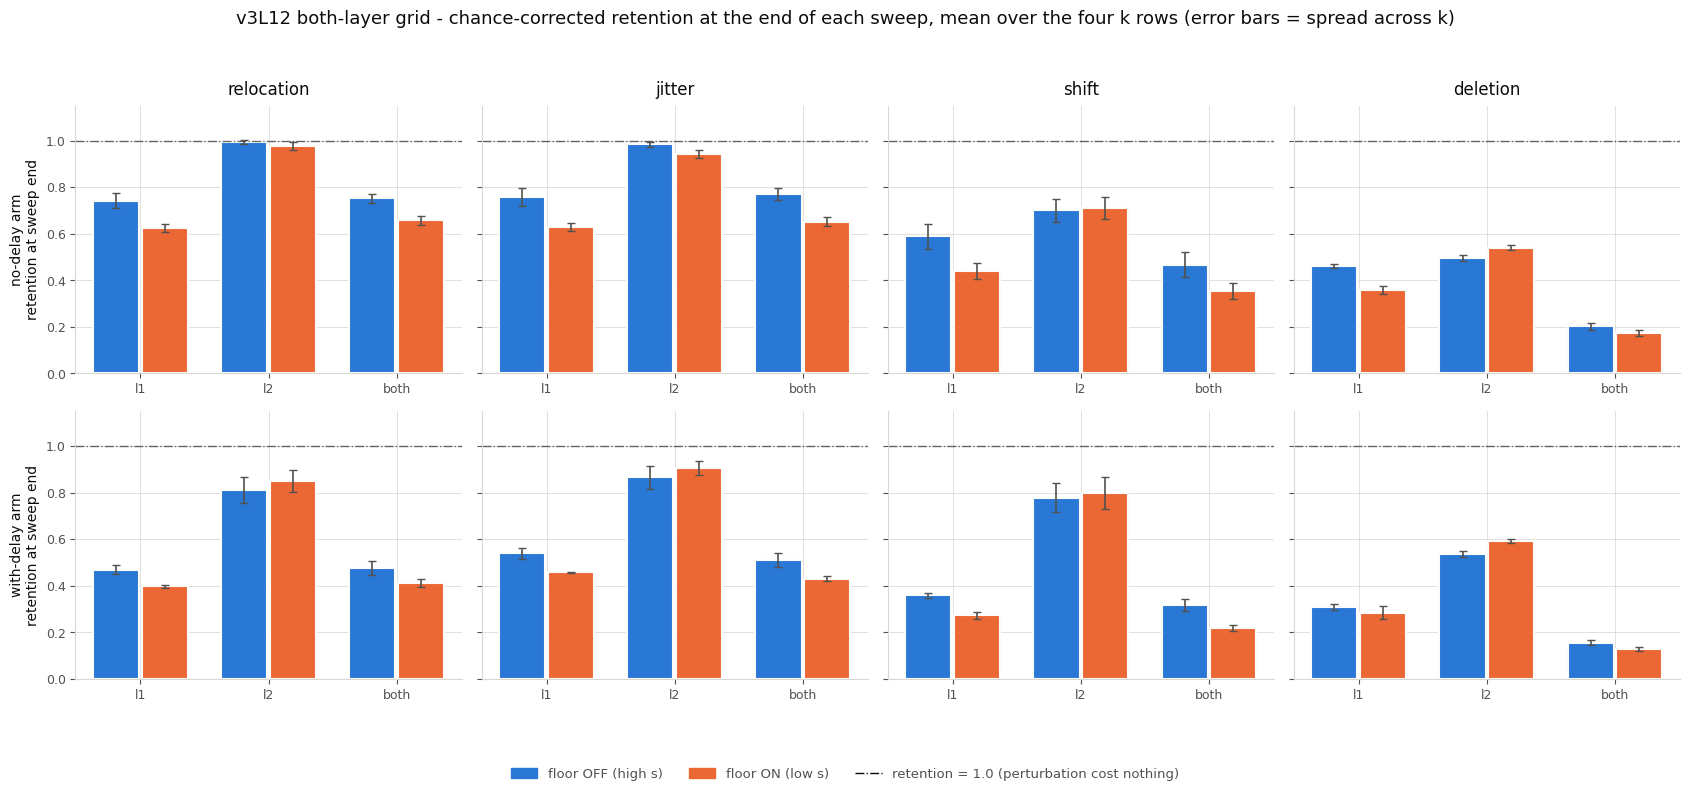

In [8]:
figure, axes = plt.subplots(2, 4, figsize=(17, 7.6), sharey=True)
width = 0.36

for row, (arm, arm_label) in enumerate(ARMS):
    levels = k_levels(arm)
    for col, (label, folder, stem, _, _, _) in enumerate(PERTURBATIONS):
        axis = axes[row][col]
        per_setup = load_per_setup(arm, folder, stem)
        positions = np.arange(len(SITES))

        for index, floor in enumerate([0.0, 1.0]):
            means, errs = [], []
            for site, _ in SITES:
                values = [per_setup[f"k{k:g}_floor{floor:g}"][f"retention_{site}"]
                          for k in levels]
                means.append(float(np.mean(values)))
                errs.append(float(np.std(values)))
            offset = (index - 0.5) * (width + 0.02)
            axis.bar(positions + offset, means, width, yerr=errs, capsize=3,
                     color=FLOOR_COLOUR[floor], edgecolor="#fcfcfb", linewidth=1.5,
                     error_kw=dict(ecolor=INK_MUTED, lw=1.2), zorder=2)

        axis.axhline(1.0, color=INK, linewidth=1, linestyle="-.", alpha=0.6)
        axis.set_xticks(positions)
        axis.set_xticklabels([site for site, _ in SITES])
        style_axis(axis)
        if col == 0:
            axis.set_ylabel(f"{arm_label}\nretention at sweep end", fontsize=10,
                            color=INK)
        if row == 0:
            axis.set_title(label, fontsize=12, color=INK, pad=8)

axes[0][0].set_ylim(0.0, 1.15)

handles = [
    plt.Rectangle((0, 0), 1, 1, color=FLOOR_COLOUR[0.0], label="floor OFF (high s)"),
    plt.Rectangle((0, 0), 1, 1, color=FLOOR_COLOUR[1.0], label="floor ON (low s)"),
    plt.Line2D([], [], color=INK, linestyle="-.", linewidth=1,
               label="retention = 1.0 (perturbation cost nothing)"),
]
figure.legend(handles=handles, loc="lower center", ncol=3, frameon=False,
              fontsize=9.5, labelcolor=INK_MUTED, bbox_to_anchor=(0.5, -0.05))
figure.suptitle("v3L12 both-layer grid - chance-corrected retention at the end of "
                "each sweep, mean over the four k rows (error bars = spread "
                "across k)", fontsize=13, color=INK)
figure.tight_layout(rect=(0, 0.05, 1, 0.95))
plt.show()

## 7. Did the manipulation work? — `a`, `s`, and their correlations

Everything above is only interpretable if the two knobs did what they were built to do:
the ceiling moves `a` (spikes per **active** neuron) and the floor moves `s` (silent
fraction), *independently*, and here they must do it at **both** layers rather than at
one. This is the design acceptance check of document 7.

### 7a. The two knobs, per layer and pooled

Twelve panels: rows alternate `a` and `s` within each arm, columns are layer 1, layer 2
and the pooled network. The grey band on the `a` panels is that layer's *unconstrained*
firing measured on the v1 checkpoints (document 7 §2a) — the distance from band to curve
is how hard the ceiling bit, and the span of the curve is the row axis a `β_a`
regression has to work with.

What to look for, in order:

1. **neither layer collapsed** at the `k` = 1, floor-OFF corner — the most dangerous
   cell in the project, two one-sided-toward-zero ceilings with nothing opposing either
   (document 7 §7 point 6);
2. `s` **widely separated between the two floor levels at both layers** — a floor that
   bites at one layer only leaves the column knob doing half its job, and makes the
   pooled `s_net` axis a statement about one layer;
3. `s` **roughly flat in `k` within a column**, which the probe already flagged as
   partially violated in the floor-OFF column.

### 7b. The correlations

One point per checkpoint, 24 per arm. The first three panels are ρ(`a`, `s`) at layer
1, at layer 2, and pooled; **the pooled one is the acceptance number**, read against the
observational baseline of **−0.879** (no-delay, which fails |ρ| ≤ 0.5 outright) and
**+0.042** (delay, which already passes — there this design buys the *controlled*
floor-on/floor-off contrast at matched `a`, not decorrelation).

The fourth panel is the one with no analogue in the sibling notebooks: ρ(`s1`, `s2`),
the cross-layer selectivity. Under v1's layer-1-only penalty this was **−0.829** in the
no-delay arm — squeezing layer 1 made layer 2 *less* selective — and that number is why
this grid exists. It is **not** an acceptance criterion; it is a sign check. If it has
not turned clearly positive, the column knob is not a network-wide selectivity
manipulation.

ρ(`a1`, `a2`) is printed as a diagnostic and is **explicitly excluded** from the
pass/fail check: both knobs act on both layers, so the two layers' activity is moved
together by construction and this design cannot and does not try to break it.

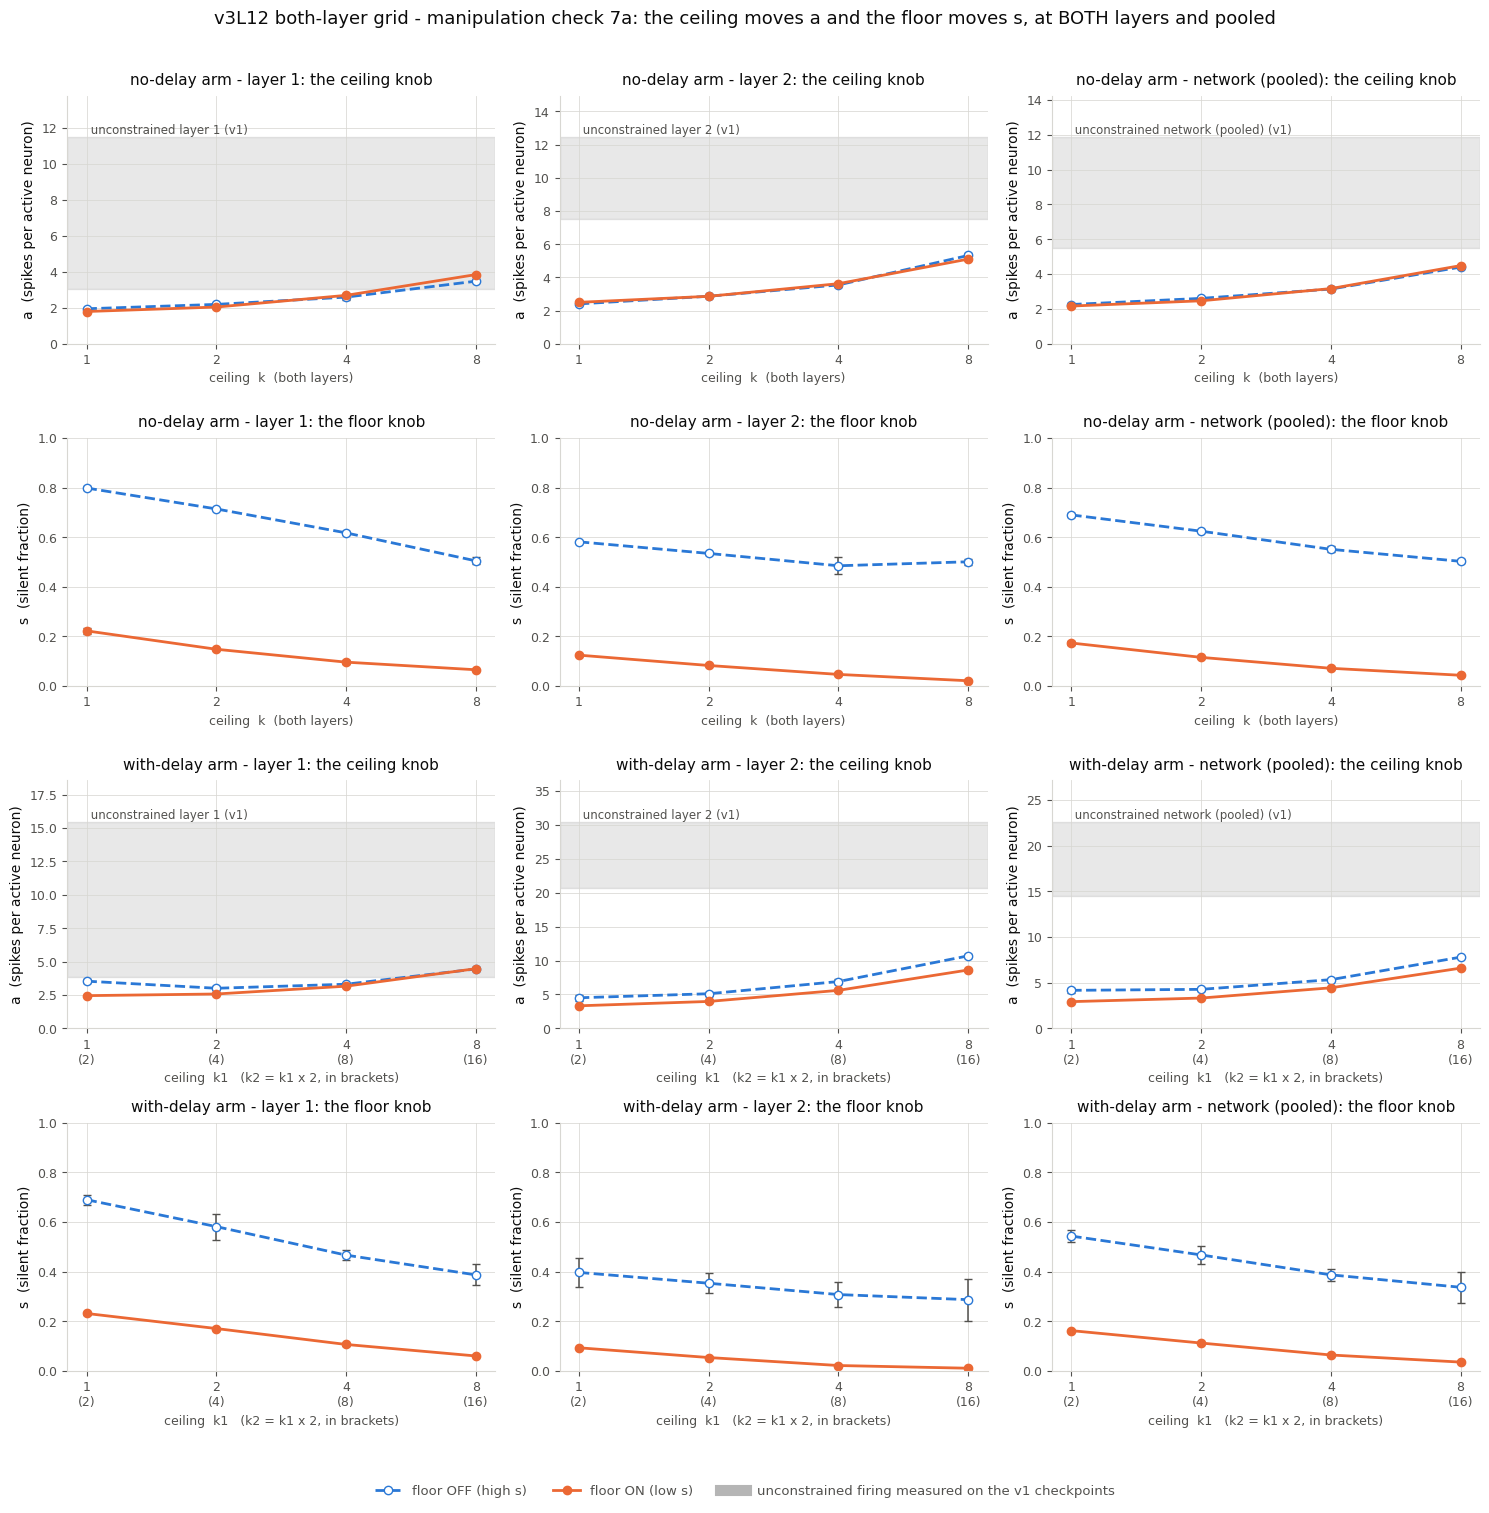

In [9]:
LAYER_COLUMNS = [("l1", "layer 1"), ("l2", "layer 2"), ("net", "network (pooled)")]

figure, axes = plt.subplots(4, 3, figsize=(15, 15))

for arm_index, (arm, arm_label) in enumerate(ARMS):
    per_setup = load_per_setup(arm, "shd", "shd")
    levels = k_levels(arm)
    ratio = k_ratio(arm)

    for col, (suffix, layer_label) in enumerate(LAYER_COLUMNS):
        for offset, (statistic, ylabel) in enumerate([
                ("spikes_per_active_neuron", "a  (spikes per active neuron)"),
                ("silent_fraction", "s  (silent fraction)")]):
            axis = axes[arm_index * 2 + offset][col]
            key = f"{statistic}_{suffix}"
            for floor in (0.0, 1.0):
                rows = [per_setup[f"k{k:g}_floor{floor:g}"] for k in levels]
                means = np.array([row[key] for row in rows])
                errs = np.array([row[f"{key}_std"] for row in rows])
                axis.errorbar(levels, means, yerr=errs, capsize=3, linewidth=2,
                              markersize=6, color=FLOOR_COLOUR[floor],
                              ecolor=INK_MUTED, elinewidth=1.1,
                              **FLOOR_STYLE[floor])
            axis.set_xscale("log", base=2)
            axis.set_xticks(levels)
            axis.set_xticklabels(k_tick_labels(arm))
            axis.set_xlabel(k_axis_label(arm), fontsize=9, color=INK_MUTED)
            axis.set_ylabel(ylabel, fontsize=10, color=INK)
            style_axis(axis)

            if statistic == "spikes_per_active_neuron":
                natural_low, natural_high = NATURAL_A[arm][suffix]
                axis.axhspan(natural_low, natural_high, color=INK, alpha=0.09,
                             zorder=0)
                axis.text(levels[0], natural_high, f" unconstrained {layer_label} (v1)",
                          ha="left", va="bottom", fontsize=8.5, color=INK_MUTED)
                axis.set_ylim(0, natural_high * 1.20)
                axis.set_title(f"{arm_label} - {layer_label}: the ceiling knob",
                               fontsize=11, color=INK, pad=8)
            else:
                axis.set_ylim(0, 1.0)
                axis.set_title(f"{arm_label} - {layer_label}: the floor knob",
                               fontsize=11, color=INK, pad=8)

handles = [
    plt.Line2D([], [], color=FLOOR_COLOUR[0.0], linewidth=2, linestyle="--",
               marker="o", markerfacecolor="white", label="floor OFF (high s)"),
    plt.Line2D([], [], color=FLOOR_COLOUR[1.0], linewidth=2, linestyle="-",
               marker="o", label="floor ON (low s)"),
    plt.Line2D([], [], color=INK, alpha=0.3, linewidth=8,
               label="unconstrained firing measured on the v1 checkpoints"),
]
figure.legend(handles=handles, loc="lower center", ncol=3, frameon=False,
              fontsize=9.5, labelcolor=INK_MUTED, bbox_to_anchor=(0.5, -0.02))
figure.suptitle("v3L12 both-layer grid - manipulation check 7a: the ceiling moves a "
                "and the floor moves s, at BOTH layers and pooled",
                fontsize=13, color=INK)
figure.tight_layout(rect=(0, 0.025, 1, 0.97))
plt.show()

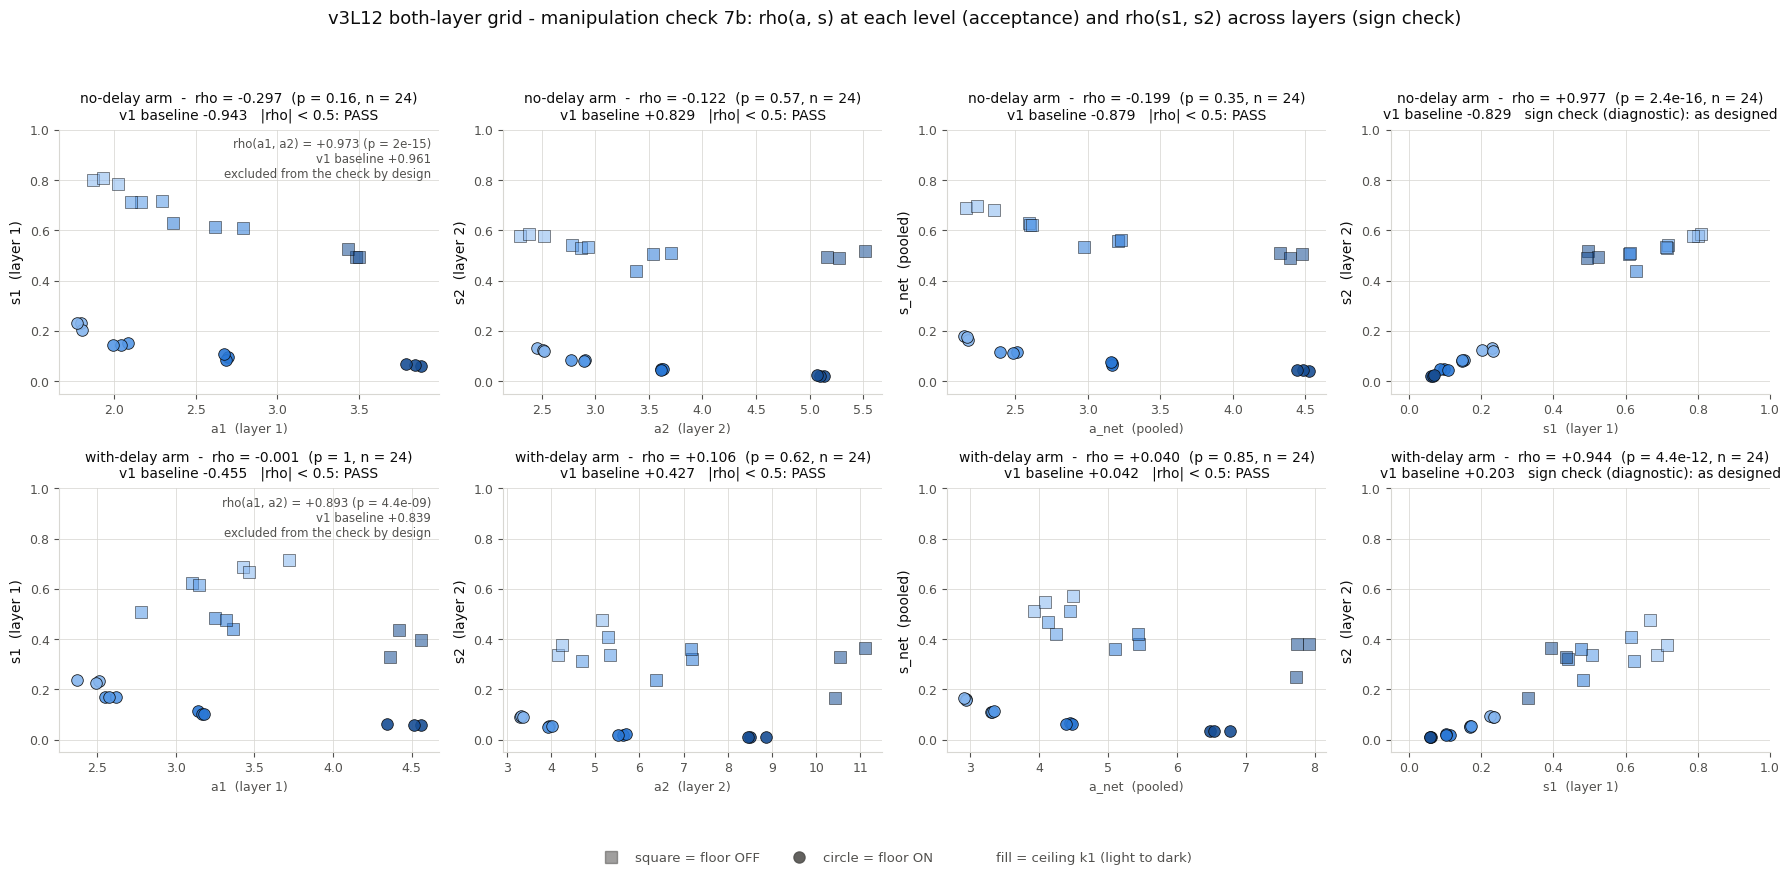

In [10]:
def pearson(x: np.ndarray, y: np.ndarray) -> tuple:
    """Return (r, two-sided p) for a Pearson correlation, via scipy if available."""
    try:
        from scipy.stats import pearsonr
        r, p = pearsonr(x, y)
        return float(r), float(p)
    except ImportError:                      # p is optional; r is not
        return float(np.corrcoef(x, y)[0, 1]), float("nan")


# (key, x statistic, y statistic, x label, y label, is this an acceptance check?)
SCATTERS = [
    ("l1", "spikes_per_active_neuron_l1", "silent_fraction_l1",
     "a1  (layer 1)", "s1  (layer 1)", True),
    ("l2", "spikes_per_active_neuron_l2", "silent_fraction_l2",
     "a2  (layer 2)", "s2  (layer 2)", True),
    ("net", "spikes_per_active_neuron_net", "silent_fraction_net",
     "a_net  (pooled)", "s_net  (pooled)", True),
    ("s1s2", "silent_fraction_l1", "silent_fraction_l2",
     "s1  (layer 1)", "s2  (layer 2)", False),
]

figure, axes = plt.subplots(2, 4, figsize=(18, 8.5))

for row, (arm, arm_label) in enumerate(ARMS):
    per_checkpoint = load_results(arm, "shd", "shd")["per_checkpoint"]
    rows = list(per_checkpoint.values())

    for col, (key, x_key, y_key, xlabel, ylabel, is_acceptance) in enumerate(SCATTERS):
        axis = axes[row][col]
        for entry in rows:
            axis.scatter(entry[x_key], entry[y_key], s=70,
                         color=K_COLOURS[entry["ceiling_k"]],
                         marker="o" if entry["floor_strength"] else "s",
                         edgecolor=INK, linewidth=0.6,
                         alpha=0.9 if entry["floor_strength"] else 0.55, zorder=3)

        x_values = np.array([entry[x_key] for entry in rows])
        y_values = np.array([entry[y_key] for entry in rows])
        r_value, p_value = pearson(x_values, y_values)
        baseline = OBSERVED_RHO[arm][key]

        if is_acceptance:
            verdict = "PASS" if abs(r_value) < 0.5 else "FAIL"
            second_line = (f"v1 baseline {baseline:+.3f}   |rho| < 0.5: {verdict}")
        else:
            verdict = "as designed" if r_value > 0 else "NOT as designed"
            second_line = (f"v1 baseline {baseline:+.3f}   sign check "
                           f"(diagnostic): {verdict}")

        axis.set_xlabel(xlabel, fontsize=9, color=INK_MUTED)
        axis.set_ylabel(ylabel, fontsize=10, color=INK)
        axis.set_ylim(-0.05, 1.0)
        if key == "s1s2":
            axis.set_xlim(-0.05, 1.0)
        axis.set_title(f"{arm_label}  -  rho = {r_value:+.3f}  "
                       f"(p = {p_value:.2g}, n = {len(rows)})\n{second_line}",
                       fontsize=10, color=INK, pad=8)
        style_axis(axis)

    # The cross-layer activity confound: reported, never part of the verdict.
    activity_r, activity_p = pearson(
        np.array([entry["spikes_per_active_neuron_l1"] for entry in rows]),
        np.array([entry["spikes_per_active_neuron_l2"] for entry in rows]))
    axes[row][0].text(
        0.98, 0.97,
        f"rho(a1, a2) = {activity_r:+.3f} (p = {activity_p:.2g})\n"
        f"v1 baseline {'+0.961' if arm == 'nodelay' else '+0.839'}\n"
        f"excluded from the check by design",
        transform=axes[row][0].transAxes, ha="right", va="top", fontsize=8.5,
        color=INK_MUTED)

handles = [
    plt.Line2D([], [], color=INK_MUTED, linestyle="none", marker="s", markersize=8,
               alpha=0.55, label="square = floor OFF"),
    plt.Line2D([], [], color=INK_MUTED, linestyle="none", marker="o", markersize=8,
               alpha=0.9, label="circle = floor ON"),
    plt.Line2D([], [], color=INK_MUTED, linestyle="none",
               label="fill = ceiling k1 (light to dark)"),
]
figure.legend(handles=handles, loc="lower center", ncol=3, frameon=False,
              fontsize=9.5, labelcolor=INK_MUTED, bbox_to_anchor=(0.5, -0.04))
figure.suptitle("v3L12 both-layer grid - manipulation check 7b: rho(a, s) at each "
                "level (acceptance) and rho(s1, s2) across layers (sign check)",
                fontsize=13, color=INK)
figure.tight_layout(rect=(0, 0.04, 1, 0.94))
plt.show()

## 8. The same numbers as tables

Kept so the figures are never the only way to read the result, and so exact values can
be quoted without measuring pixels.

**Table 1 — the manipulation**, per arm: what the grid actually achieved at each layer
and pooled. `over-k` is the fraction of neuron–sample pairs still exceeding that layer's
ceiling; document 7's residual limitation is that the ceiling leaks more at layer 2 than
at layer 1 in the delay arm, and this column is where that shows.

**Table 2 — the sweep endpoints**, one table per arm per injection site: accuracy at the
hardest point of each sweep, with the `BASELINE` row giving the non-sparse network at
the same endpoint. The relocation baseline sweep stops at `f = 0.9` where the v3L12
sweep runs to `f = 1.0`, so that column's baseline is marked `reloc(.9)`; the `both`
site has no baseline row at all, for the reason given in §5.

In [11]:
header = (f"{'arm':<15}{'setup':<12}{'clean acc':>16}"
          f"{'a1':>7}{'s1':>7}{'ok1':>7}"
          f"{'a2':>8}{'s2':>7}{'ok2':>7}"
          f"{'a_net':>9}{'s_net':>7}")
print("TABLE 1 - the manipulation, per layer and pooled")
print(header)
print("-" * len(header))

for arm, arm_label in ARMS:
    per_setup = load_per_setup(arm, "shd", "shd")
    for tag, entry in per_setup.items():
        clean = f"{entry['clean_acc']:.3f}+-{entry['clean_acc_std']:.3f}"
        print(f"{arm_label:<15}{tag:<12}{clean:>16}"
              f"{entry['spikes_per_active_neuron_l1']:>7.2f}"
              f"{entry['silent_fraction_l1']:>7.3f}"
              f"{entry['over_k_fraction_l1']:>7.3f}"
              f"{entry['spikes_per_active_neuron_l2']:>8.2f}"
              f"{entry['silent_fraction_l2']:>7.3f}"
              f"{entry['over_k_fraction_l2']:>7.3f}"
              f"{entry['spikes_per_active_neuron_net']:>9.2f}"
              f"{entry['silent_fraction_net']:>7.3f}")
    print()

TABLE 1 - the manipulation, per layer and pooled
arm            setup              clean acc     a1     s1    ok1      a2     s2    ok2    a_net  s_net
------------------------------------------------------------------------------------------------------
no-delay arm   k1_floor0       0.480+-0.012   1.94  0.799  0.074    2.40  0.582  0.232     2.25  0.690
no-delay arm   k1_floor1       0.525+-0.014   1.79  0.223  0.333    2.49  0.125  0.592     2.16  0.174
no-delay arm   k2_floor0       0.501+-0.014   2.19  0.714  0.069    2.86  0.535  0.193     2.60  0.625
no-delay arm   k2_floor1       0.535+-0.003   2.04  0.148  0.186    2.86  0.083  0.432     2.46  0.116
no-delay arm   k4_floor0       0.518+-0.014   2.59  0.618  0.055    3.54  0.485  0.138     3.14  0.551
no-delay arm   k4_floor1       0.572+-0.010   2.69  0.096  0.104    3.62  0.047  0.258     3.17  0.072
no-delay arm   k8_floor0       0.534+-0.008   3.47  0.505  0.035    5.32  0.501  0.089     4.40  0.503
no-delay arm   k8_floor1

In [12]:
header = (f"{'arm':<15}{'setup':<12}{'clean acc':>16}"
          f"{'reloc(1)':>10}{'jit(25)':>9}{'shift(25)':>10}{'del(.8)':>9}")

print("TABLE 2 - accuracy at the end of each sweep, by injection site")
for site, site_label in SITES:
    print()
    print(f"### injected at {site_label}  (site = {site})")
    print(header)
    print("-" * len(header))
    for arm, arm_label in ARMS:
        per_setup = load_per_setup(arm, "shd", "shd")
        sweeps = {label: load_per_setup(arm, folder, stem)
                  for label, folder, stem, _, _, _ in PERTURBATIONS}
        for tag, entry in per_setup.items():
            endpoints = []
            for label, _, _, prefix, _, _ in PERTURBATIONS:
                sweep = sweeps[label][tag][f"{prefix}_{site}"]
                endpoints.append(sweep[list(sweep)[-1]]["mean"])
            clean = f"{entry['clean_acc']:.3f}+-{entry['clean_acc_std']:.3f}"
            print(f"{arm_label:<15}{tag:<12}{clean:>16}"
                  f"{endpoints[0]:>10.3f}{endpoints[1]:>9.3f}"
                  f"{endpoints[2]:>10.3f}{endpoints[3]:>9.3f}")

        # The non-sparse reference, where one exists for this site.
        base_endpoints, base_cleans = [], []
        for _, _, _, _, templates, _ in PERTURBATIONS:
            baseline = load_baseline(arm, templates, site)
            if baseline is None:
                break
            base_cleans.append(baseline[0.0][0])
            base_endpoints.append(baseline[max(baseline)][0])
        if not base_endpoints:
            print(f"{arm_label:<15}{'BASELINE':<12}"
                  f"{'-- none exists for this site --':>16}")
            print()
            continue
        if max(base_cleans) - min(base_cleans) > 1e-9:
            clean = (f"{np.mean(base_cleans):.3f}"
                     f"({min(base_cleans):.3f}-{max(base_cleans):.3f})")
        else:
            clean = f"{base_cleans[0]:.3f}"
        print(f"{arm_label:<15}{'BASELINE':<12}{clean:>16}"
              f"{base_endpoints[0]:>10.3f}{base_endpoints[1]:>9.3f}"
              f"{base_endpoints[2]:>10.3f}{base_endpoints[3]:>9.3f}"
              f"   <- reloc column is f = 0.9")
        print()

TABLE 2 - accuracy at the end of each sweep, by injection site

### injected at hidden layer 1  (site = l1)
arm            setup              clean acc  reloc(1)  jit(25) shift(25)  del(.8)
---------------------------------------------------------------------------------
no-delay arm   k1_floor0       0.480+-0.012     0.386    0.395     0.335    0.253
no-delay arm   k1_floor1       0.525+-0.014     0.352    0.360     0.279    0.229
no-delay arm   k2_floor0       0.501+-0.014     0.378    0.390     0.321    0.257
no-delay arm   k2_floor1       0.535+-0.003     0.360    0.360     0.272    0.229
no-delay arm   k4_floor0       0.518+-0.014     0.405    0.411     0.318    0.265
no-delay arm   k4_floor1       0.572+-0.010     0.375    0.373     0.275    0.226
no-delay arm   k8_floor0       0.534+-0.008     0.389    0.389     0.299    0.269
no-delay arm   k8_floor1       0.568+-0.009     0.359    0.361     0.251    0.229
no-delay arm   BASELINE    0.575(0.572-0.584)     0.347    0.294     0.1

## 9. What is visible in these figures

Descriptive only — what the panels above show, at the level a reader can check against
them. The regressions, the effect sizes and the H1′/H2 verdict belong to
`v3_analysis/` and to
[the progress document](../../../docs/progress/sparse_network_bothLayer_test_progress.md),
not here.

**The design's central claim holds.** ρ(`s1`, `s2`) is **+0.977** (no-delay) and
**+0.944** (delay), against v1's **−0.829** and **+0.203**. Under the layer-1-only
penalty the two layers' selectivity moved in *opposite* directions; here they move
together. This is the one number §1 of document 7 was written about, and the sign flip
is unambiguous rather than marginal.

**The pooled confound broke in the arm that needed it.** ρ(`a_net`, `s_net`) is
**−0.199** (p = .35) in the no-delay arm against an observational **−0.879** — inside
the |ρ| ≤ 0.5 threshold with room to spare. The delay arm stays passing at **+0.040**
against **+0.042**, which is what it was expected to do: there the design buys the
controlled contrast, not decorrelation. Both layers pass individually too (−0.297 /
−0.122 no-delay, −0.001 / +0.106 delay), so the decorrelation is not a pooling artifact.

**The `a1`/`a2` caveat is confirmed rather than resolved**, exactly as document 7 §7
point 1 predicted: ρ(`a1`, `a2`) = **+0.973 / +0.893**. Any β from this grid is a
network-level coefficient.

**Layer 2 is much the cheaper place to be perturbed.** Averaged over the grid,
end-of-sweep retention at `l2` beats `l1` on every perturbation in both arms — .985 vs
.683 (no-delay relocation), .830 vs .434 (delay relocation), and the gap survives on
jitter, shift and deletion. Whether that means layer 2 carries less of the timing code
or merely that damage there has one fewer layer to propagate through is not something
these panels can separate.

**`both` is not a uniform escalation over `l1`, and which perturbations escalate is the
interesting part.** Mean retention, `both` minus `l1`:

| | relocation | jitter | shift | deletion |
|---|---|---|---|---|
| no-delay | **+.022** | **+.018** | −.104 | **−.223** |
| delay | **+.011** | −.028 | −.049 | **−.154** |

Relocation and jitter **saturate**: adding the layer-2 insult on top of the layer-1 one
changes nothing measurable (the small positive signs are within the spread across
setups, not a real improvement). Both of those redistribute spikes *inside* a window and
hold count exactly, so once layer 1's placement code is destroyed there is little left
for a second pass to take. Shift compounds modestly and **deletion compounds strongly** —
and deletion is the one perturbation that does not preserve count. That is the ordering
a compounding argument predicts, and it is the reason document 7 §5 step 3 insisted the
`both` site be treated as its own quantity rather than a check on the other two.

**The manipulation itself worked at both layers.** In §7a both `a` panels rise
monotonically with `k` at both layers and in both arms, both `s` panels are widely
separated by the floor at both layers (no-delay: .80 → .22 at L1 and .58 → .13 at L2 at
`k1 = 1`), no cell collapsed at the `k = 1` floor-OFF corner, and the delay arm's
`k1 = 1` cells sit at over-`k` .371 / .506 — the residual layer-2 ceiling leak document
7 flagged, visible in Table 1's `ok2` column.

**One violation carries over from the probe.** `s` is not flat in `k` within the
floor-OFF column: it drifts .80 → .51 at layer 1 in the no-delay arm (29 points) and
.69 → .39 in the delay arm. This is criterion 2, partially violated in every grid in
this project, and it means the column knob is not a pure `s` manipulation.